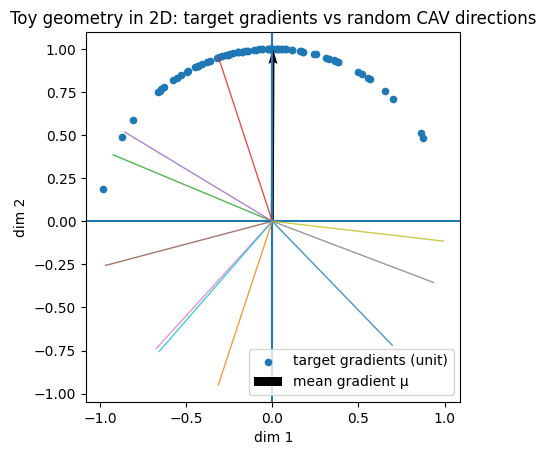

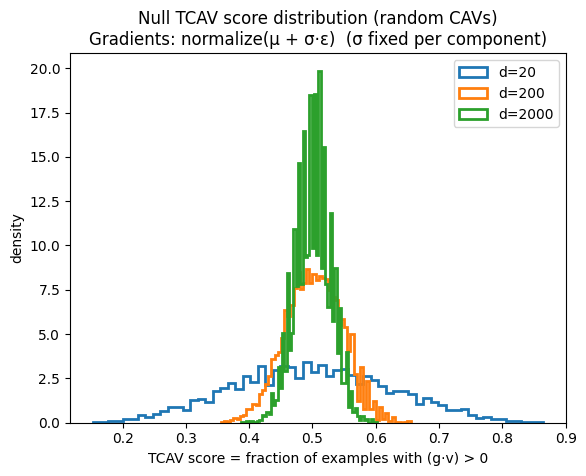

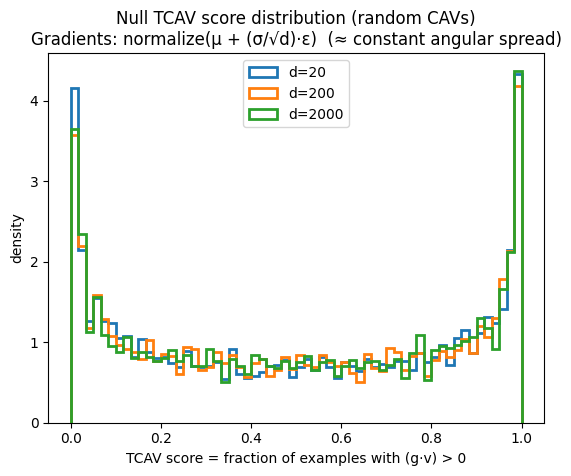

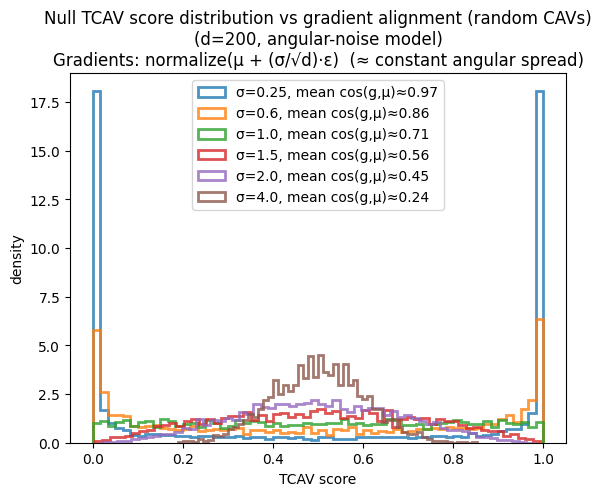

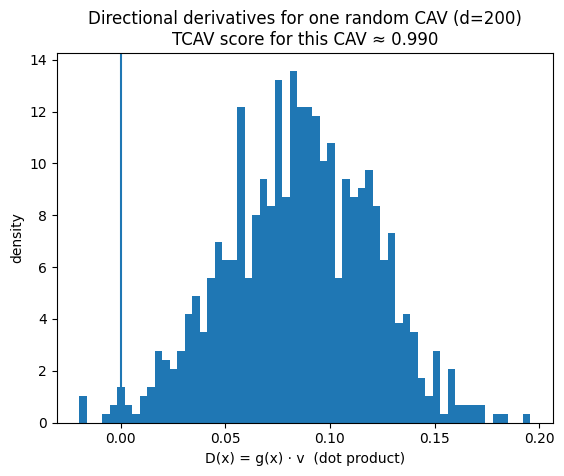

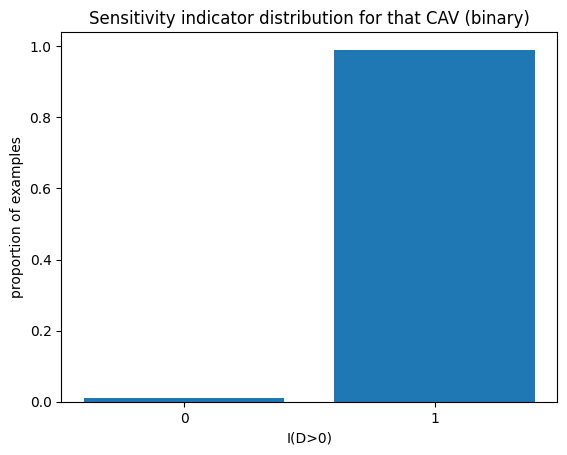

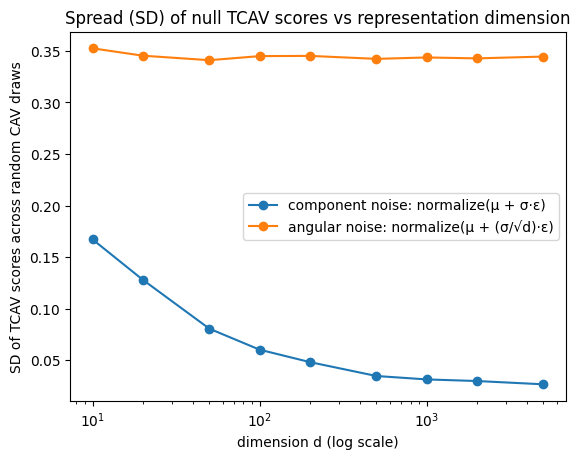

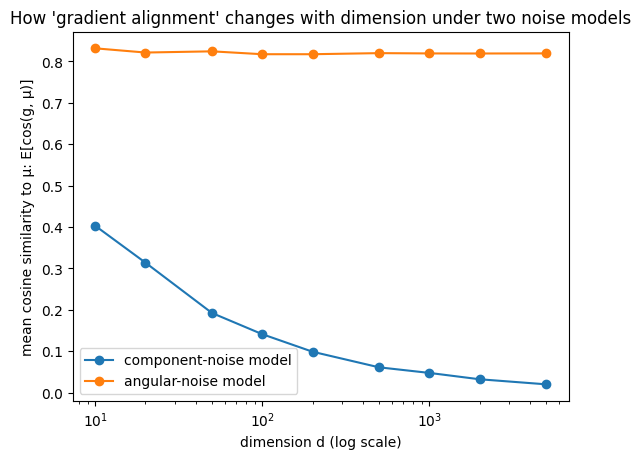

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

def unit(x, axis=-1, eps=1e-12):
    n = np.linalg.norm(x, axis=axis, keepdims=True)
    return x / (n + eps)

def random_unit(d, n=1):
    return unit(rng.normal(size=(n, d)))

def gen_gradients(d, n, model="angular", noise=0.7, signal=1.0):
    """
    Returns gradients g (n,d) and the mean direction mu (d,).
    model:
      - "angular": g = normalize(mu + (noise/sqrt(d))*eps)  => approx constant angular spread across d
      - "component": g = normalize(mu + noise*eps)          => angular spread increases with d (since ||eps||~sqrt(d))
    noise: dispersion control (bigger => more spread)
    signal: scales the mean direction (kept at 1.0 here because we normalize; included for completeness)
    """
    mu = random_unit(d, 1)[0]
    eps = rng.normal(size=(n, d))
    if model == "angular":
        g = signal * mu + (noise / np.sqrt(d)) * eps
    elif model == "component":
        g = signal * mu + noise * eps
    else:
        raise ValueError("Unknown model")
    g = unit(g)
    return g, mu

def tcav_null_distribution(g, m_cavs=5000):
    """
    For a fixed set of gradients g (n,d), sample random unit CAVs v and compute:
      - directional derivatives D = g @ v  (n,)
      - sensitivity indicator I(D>0)
      - TCAV score = mean I
    Returns tcav_scores shape (m_cavs,).
    """
    n, d = g.shape
    V = random_unit(d, m_cavs)  # (m,d)
    D = g @ V.T                 # (n,m)
    tcav = (D > 0).mean(axis=0)
    return tcav

# --- 1) A simple 2D picture: gradients clustered around a mean direction + random CAVs ---
d2 = 2
g2, mu2 = gen_gradients(d2, n=80, model="angular", noise=0.6)
V2 = random_unit(d2, 10)

plt.figure()
plt.axhline(0)
plt.axvline(0)
plt.scatter(g2[:,0], g2[:,1], s=20, label="target gradients (unit)")
plt.quiver([0],[0],[mu2[0]],[mu2[1]], angles='xy', scale_units='xy', scale=1, width=0.008, label="mean gradient μ")
# draw CAV rays
for v in V2:
    plt.plot([0, v[0]], [0, v[1]], linewidth=1, alpha=0.8)
plt.gca().set_aspect("equal", "box")
plt.title("Toy geometry in 2D: target gradients vs random CAV directions")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.legend()
plt.show()

# --- 2) Null TCAV distributions across dimensions, two gradient-noise models ---
n = 400
m = 6000

dims = [20, 200, 2000]
noise = 0.7  # moderate dispersion

# Model A: component noise (fixed per-component noise => less alignment as d grows)
plt.figure()
for d in dims:
    g, mu = gen_gradients(d, n=n, model="component", noise=noise)
    tcav = tcav_null_distribution(g, m_cavs=m)
    plt.hist(tcav, bins=60, density=True, histtype="step", linewidth=2, label=f"d={d}")

plt.title("Null TCAV score distribution (random CAVs)\nGradients: normalize(μ + σ·ε)  (σ fixed per component)")
plt.xlabel("TCAV score = fraction of examples with (g·v) > 0")
plt.ylabel("density")
plt.legend()
plt.show()

# Model B: angular noise (noise scaled ~1/sqrt(d) => roughly constant angular spread across d)
plt.figure()
for d in dims:
    g, mu = gen_gradients(d, n=n, model="angular", noise=noise)
    tcav = tcav_null_distribution(g, m_cavs=m)
    plt.hist(tcav, bins=60, density=True, histtype="step", linewidth=2, label=f"d={d}")

plt.title("Null TCAV score distribution (random CAVs)\nGradients: normalize(μ + (σ/√d)·ε)  (≈ constant angular spread)")
plt.xlabel("TCAV score = fraction of examples with (g·v) > 0")
plt.ylabel("density")
plt.legend()
plt.show()

# --- 3) How gradient dispersion changes the null (fix d) ---
d = 200
noise_levels = [0.25, 0.6, 1.0, 1.5,  2.0, 4.0]  # tight -> moderate -> diffuse
plt.figure()
for sig in noise_levels:
    g, mu = gen_gradients(d, n=n, model="angular", noise=sig)
    tcav = tcav_null_distribution(g, m_cavs=m)
    mean_cos = np.mean(g @ mu)
    plt.hist(tcav, bins=60, density=True, histtype="step", linewidth=2, alpha=0.8,
             label=f"σ={sig}, mean cos(g,μ)≈{mean_cos:.2f}")

plt.title("Null TCAV score distribution vs gradient alignment (random CAVs)\n(d=200, angular-noise model)\nGradients: normalize(μ + (σ/√d)·ε)  (≈ constant angular spread)")
plt.xlabel("TCAV score")
plt.ylabel("density")
plt.legend()
plt.show()

# --- 4) Directional derivatives & sensitivity indicators for one sampled random CAV ---
d = 200
g, mu = gen_gradients(d, n=800, model="angular", noise=0.6)
v = random_unit(d, 1)[0]
D = g @ v
I = (D > 0).astype(int)
tcav_one = I.mean()

plt.figure()
plt.hist(D, bins=60, density=True)
plt.axvline(0)
plt.title(f"Directional derivatives for one random CAV (d=200)\nTCAV score for this CAV ≈ {tcav_one:.3f}")
plt.xlabel("D(x) = g(x) · v  (dot product)")
plt.ylabel("density")
plt.show()

plt.figure()
plt.hist(I, bins=[-0.5, 0.5, 1.5], density=True, rwidth=0.8)
plt.title("Sensitivity indicator distribution for that CAV (binary)")
plt.xlabel("I(D>0)")
plt.ylabel("proportion of examples")
plt.xticks([0,1])
plt.show()

# --- 5) Empirical SD of null TCAV vs dimension (shows the role of binomial noise + geometry) ---
dims_grid = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
def sd_tcav_over_dims(model, noise, n=400, m=4000):
    sds = []
    means = []
    meancos = []
    for d in dims_grid:
        g, mu = gen_gradients(d, n=n, model=model, noise=noise)
        tcav = tcav_null_distribution(g, m_cavs=m)
        sds.append(np.std(tcav))
        means.append(np.mean(tcav))
        meancos.append(np.mean(g @ mu))
    return np.array(means), np.array(sds), np.array(meancos)

meansA, sdsA, meancosA = sd_tcav_over_dims("component", noise=0.7)
meansB, sdsB, meancosB = sd_tcav_over_dims("angular", noise=0.7)

plt.figure()
plt.plot(dims_grid, sdsA, marker="o", label="component noise: normalize(μ + σ·ε)")
plt.plot(dims_grid, sdsB, marker="o", label="angular noise: normalize(μ + (σ/√d)·ε)")
plt.xscale("log")
plt.title("Spread (SD) of null TCAV scores vs representation dimension")
plt.xlabel("dimension d (log scale)")
plt.ylabel("SD of TCAV scores across random CAV draws")
plt.legend()
plt.show()

plt.figure()
plt.plot(dims_grid, meancosA, marker="o", label="component-noise model")
plt.plot(dims_grid, meancosB, marker="o", label="angular-noise model")
plt.xscale("log")
plt.title("How 'gradient alignment' changes with dimension under two noise models")
plt.xlabel("dimension d (log scale)")
plt.ylabel("mean cosine similarity to μ: E[cos(g, μ)]")
plt.legend()
plt.show()


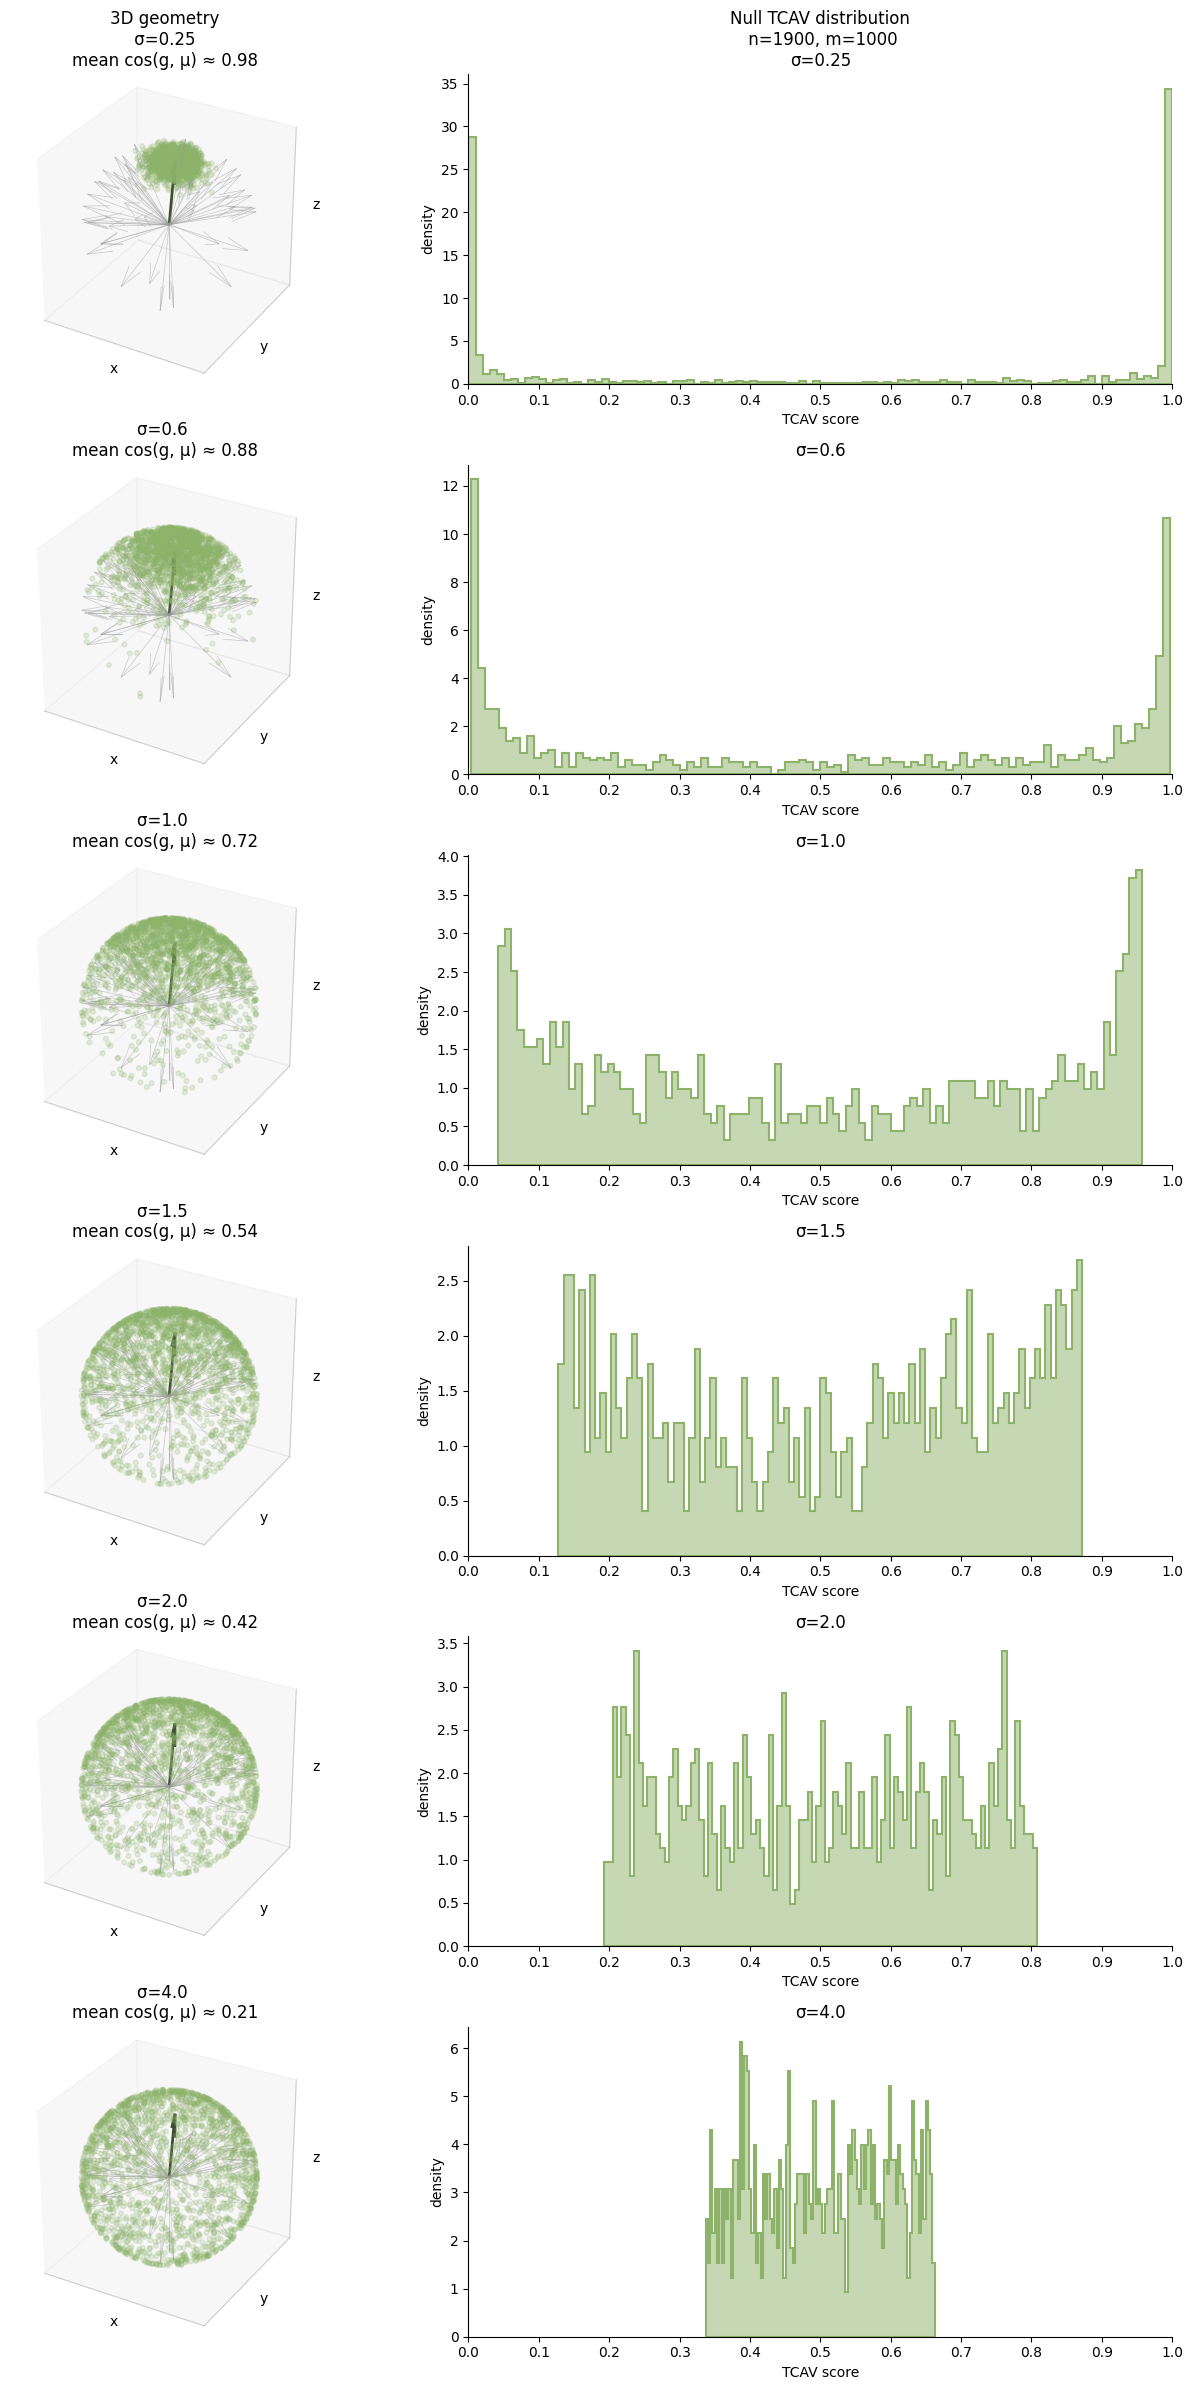

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(0)

def unit(x, axis=-1, eps=1e-12):
    n = np.linalg.norm(x, axis=axis, keepdims=True)
    return x / (n + eps)

def random_unit(d, n=1):
    return unit(rng.normal(size=(n, d)))

def gen_gradients_fixed_mu(mu, n, model="angular", noise=0.7, signal=1.0):
    """
    Generate unit gradients clustered around a FIXED mean direction mu.
    """
    d = mu.shape[0]
    eps = rng.normal(size=(n, d))
    if model == "angular":
        g = signal * mu + (noise / np.sqrt(d)) * eps
    elif model == "component":
        g = signal * mu + noise * eps
    else:
        raise ValueError("Unknown model")
    return unit(g)

def tcav_null_distribution(g, m_cavs=5000):
    n, d = g.shape
    V = random_unit(d, m_cavs)  # random unit CAVs
    D = g @ V.T
    return (D > 0).mean(axis=0)

# ---- parameters: match your original "null vs gradient alignment" section ----
d = 3
n = 1900
m = 1000
model = "angular"

# All 6 original spreads
spreads = [0.25, 0.6, 1.0, 1.5, 2.0, 4.0]

# Only for visualization (hist still uses m=6000)
n_show_cavs = 50

# Keep mu constant across all spreads
mu = random_unit(d, 1)[0]

# (Optional but useful for comparison) keep the displayed CAV arrows constant too
V_show = random_unit(d, n_show_cavs)

fig = plt.figure(figsize=(14, 24))

for row, sig in enumerate(spreads):
    g = gen_gradients_fixed_mu(mu, n=n, model=model, noise=sig)
    tcav = tcav_null_distribution(g, m_cavs=m)
    mean_cos = float(np.mean(g @ mu))

    # ---- Left: 3D geometry ----
    ax3d = fig.add_subplot(len(spreads), 2, 2*row + 1, projection="3d")

    # gradients as blue dots (normalized)
    ax3d.scatter(g[:, 0], g[:, 1], g[:, 2], s=12, alpha=0.2, color="#8CB369")

    # fixed mean direction mu as green arrow
    ax3d.quiver(0, 0, 0, mu[0], mu[1], mu[2],
                length=1.0, normalize=True, color="#3C4E2D", linewidth=2)

    # random concept vectors (grey arrows)
    ax3d.quiver(np.zeros(n_show_cavs), np.zeros(n_show_cavs), np.zeros(n_show_cavs),
                V_show[:, 0], V_show[:, 1], V_show[:, 2],
                length=1.0, normalize=True, color="0.6", linewidth=0.5, alpha=0.5)

    if row == 0:
        ax3d.set_title(f"3D geometry\n σ={sig} \nmean cos(g, μ) ≈ {mean_cos:.2f}")
    else:
        ax3d.set_title(f"σ={sig} \nmean cos(g, μ) ≈ {mean_cos:.2f}")
    ax3d.set_xlabel("x", labelpad=-10)
    ax3d.set_ylabel("y", labelpad=-10)
    ax3d.set_zlabel("z", labelpad=-10)

    ax3d.set_xticklabels([])
    ax3d.set_yticklabels([])
    ax3d.set_zticklabels([])
    ax3d.set_xticks([])
    ax3d.set_yticks([])
    ax3d.set_zticks([])



    lim = 1.05
    ax3d.set_xlim(-lim, lim)
    ax3d.set_ylim(-lim, lim)
    ax3d.set_zlim(-lim, lim)
    ax3d.grid(True)
    for axis in (ax3d.xaxis, ax3d.yaxis, ax3d.zaxis):
        axis.set_pane_color((0.7, 0.7, 0.7, 0.1))          # back planes
        axis._axinfo["grid"]["color"] = (0, 0, 0, 0.2)
        axis._axinfo["grid"]["linewidth"] = 0.15
        axis.line.set_color((0, 0, 0, 0.15))           # box edges
    try:
        ax3d.set_box_aspect((1, 1, 1))
    except Exception:
        pass

    # ---- Right: histogram (only this spread) ----
    axh = fig.add_subplot(len(spreads), 2, 2*row + 2)
    axh.hist(tcav, bins=100, density=True, histtype="stepfilled", facecolor=(140/255, 179/255, 105/255, 0.5), edgecolor="#8CB369",   linewidth=1.5 )
    if row == 0:
        axh.set_title(f"Null TCAV distribution\n n={n}, m={m}\nσ={sig}")
    else:
        axh.set_title(f"σ={sig}")
    axh.set_xlabel("TCAV score")
    axh.set_ylabel("density")
    axh.set_xlim(0, 1)
    axh.set_xticks(np.arange(0, 1.01, 0.1))
    # remove top and right spines
    axh.spines['top'].set_visible(False)
    axh.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



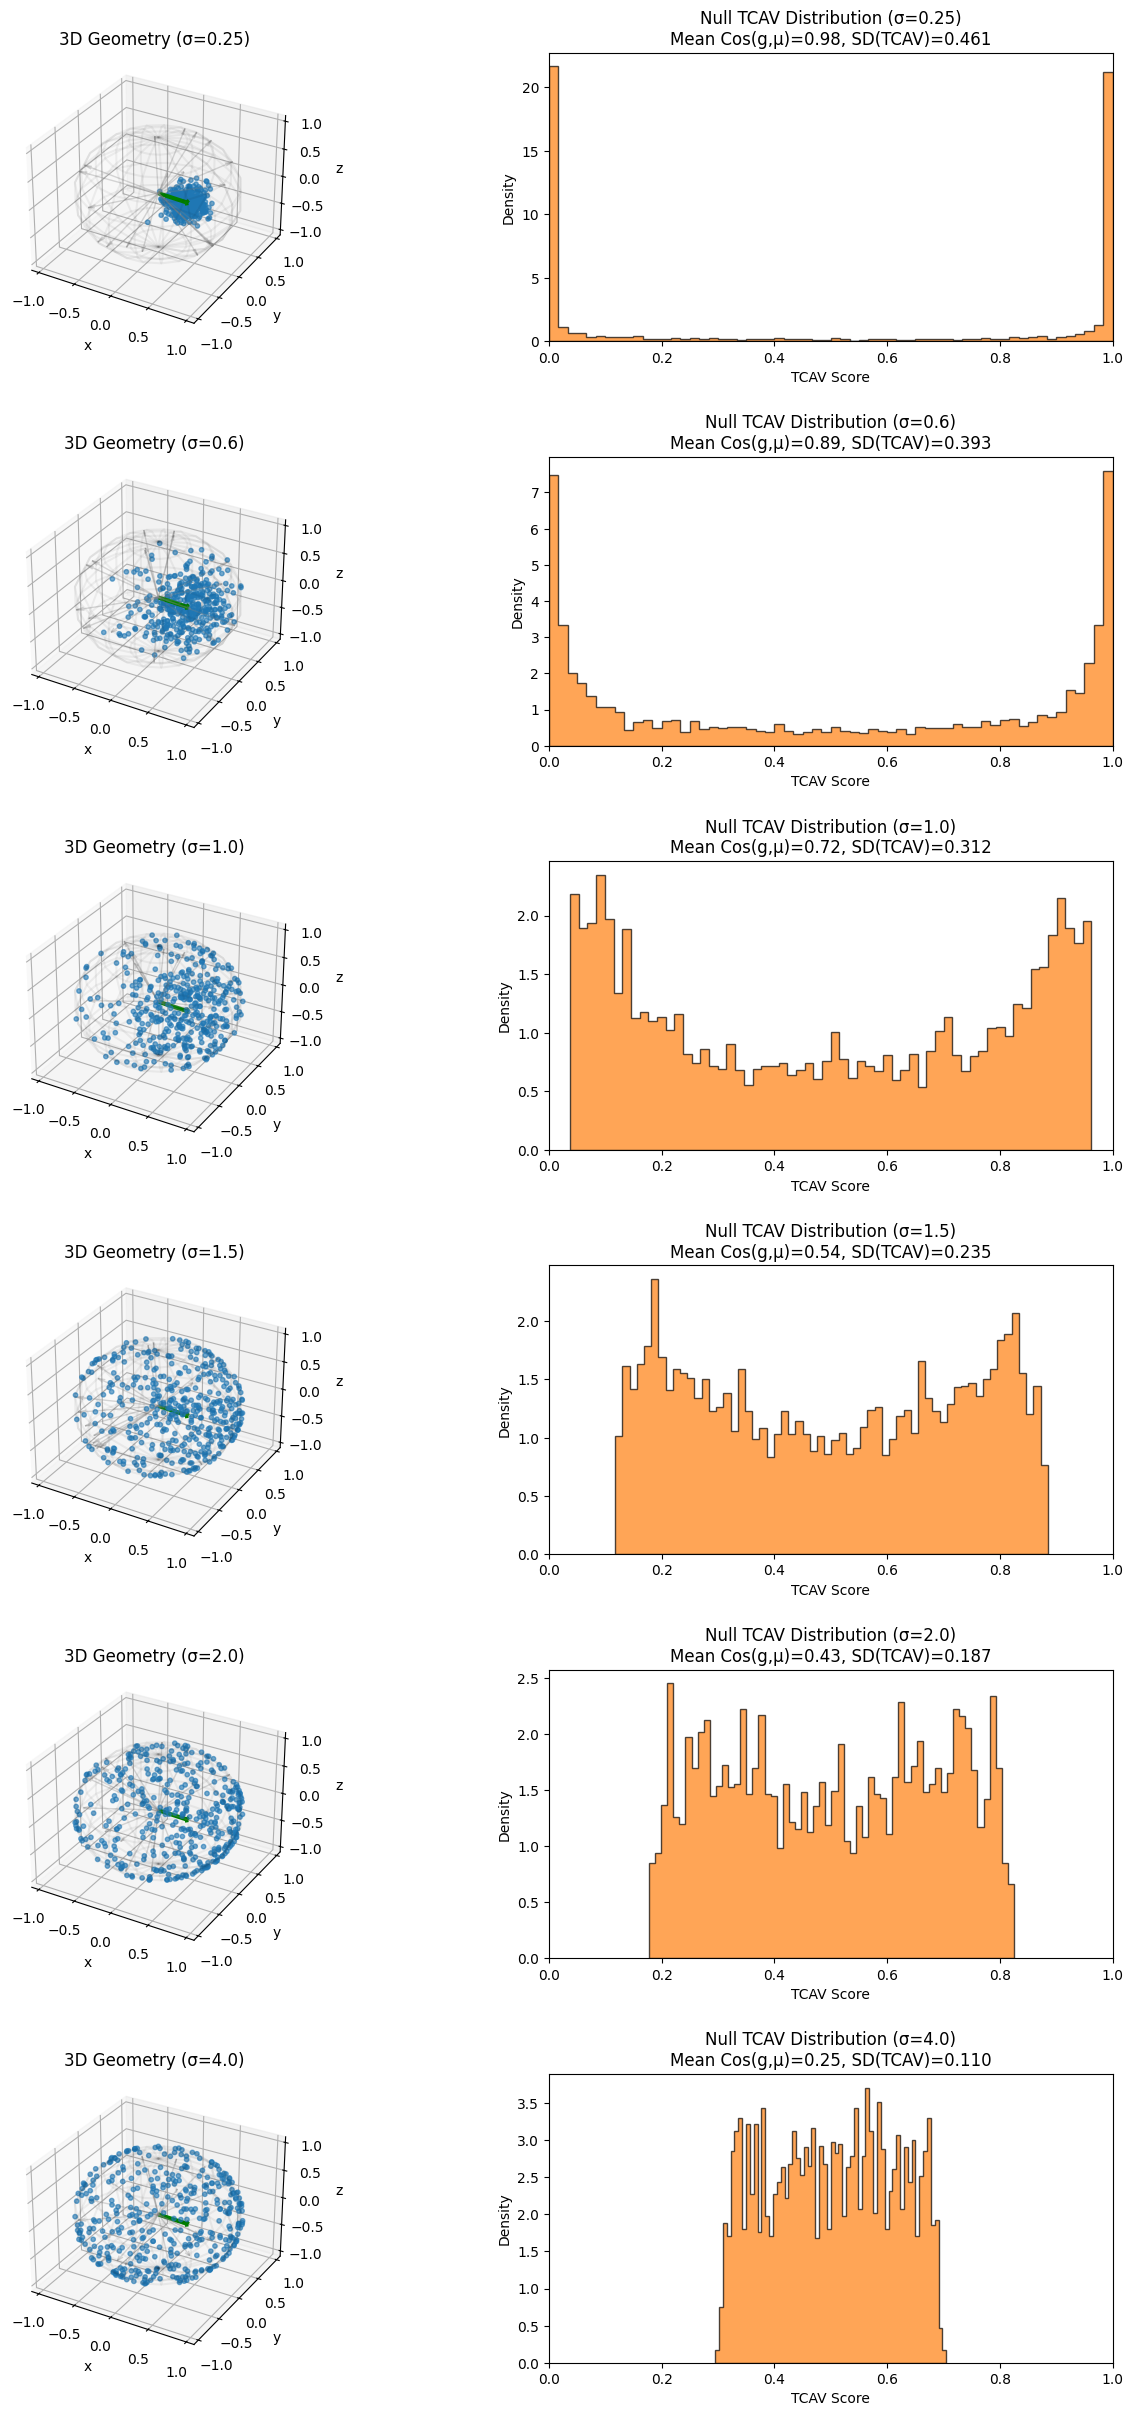

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup
rng = np.random.default_rng(7)

def unit(x, axis=-1, eps=1e-12):
    n = np.linalg.norm(x, axis=axis, keepdims=True)
    return x / (n + eps)

def random_unit(d, n=1):
    return unit(rng.normal(size=(n, d)))

def gen_gradients_fixed_mu(d, n, mu, model="angular", noise=0.7, signal=1.0):
    """
    Same as original but accepts a fixed mean direction `mu`.
    """
    eps = rng.normal(size=(n, d))
    if model == "angular":
        # noise scaled by 1/sqrt(d)
        g = signal * mu + (noise / np.sqrt(d)) * eps
    elif model == "component":
        g = signal * mu + noise * eps
    else:
        raise ValueError("Unknown model")
    g = unit(g)
    return g

def tcav_null_distribution(g, m_cavs=5000):
    n, d = g.shape
    V = random_unit(d, m_cavs)  # (m,d)
    D = g @ V.T                 # (n,m)
    # TCAV score = fraction of gradients having positive dot product with v
    tcav = (D > 0).mean(axis=0)
    return tcav, V

# 2. Parameters
d = 3           # Reduced to 3D for visualization
n = 400         # Number of gradients (blue dots)
m = 6000        # Number of CAVs for histogram statistics
noise_levels = [0.25, 0.6, 1.0, 1.5,  2.0, 4.0]

# Fix the mean direction for all plots
mu_fixed = random_unit(d, 1)[0]  # Shape (3,)

# 3. Plotting
fig = plt.figure(figsize=(16, 5 * len(noise_levels)))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

for i, sig in enumerate(noise_levels):
    # A) Generate Data
    # Use 'angular' model as requested
    g = gen_gradients_fixed_mu(d, n, mu_fixed, model="angular", noise=sig)
    
    # Calculate TCAV scores
    # We get V back just to sample some for plotting (we won't plot all 6000)
    tcav_scores, V_all = tcav_null_distribution(g, m_cavs=m)
    
    mean_cos = np.mean(g @ mu_fixed)
    
    # B) Left Plot: 3D Visualization
    ax_3d = fig.add_subplot(len(noise_levels), 2, 2*i + 1, projection='3d')
    
    # 1. Plot Gradients (Blue dots)
    ax_3d.scatter(g[:, 0], g[:, 1], g[:, 2], s=10, c='tab:blue', alpha=0.6, label='Gradients (g)')
    
    # 2. Plot Mean Direction (Green Arrow)
    # Quiver arguments: x, y, z, u, v, w
    ax_3d.quiver(0, 0, 0, mu_fixed[0], mu_fixed[1], mu_fixed[2], 
                 color='green', linewidth=3, arrow_length_ratio=0.1, label='Mean (μ)')
    
    # 3. Plot Random Concept Vectors (Grey Arrows) - Subset only
    # Plotting 20 random CAVs to avoid clutter
    num_cav_plot = 20
    V_subset = V_all[:num_cav_plot]
    for v in V_subset:
        ax_3d.quiver(0, 0, 0, v[0], v[1], v[2], 
                     color='grey', alpha=0.3, linewidth=1, arrow_length_ratio=0.1)

    # 4. Aesthetics (Sphere wireframe context)
    # Draw a faint wireframe sphere to show the unit manifold
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x_sph = np.cos(u)*np.sin(v)
    y_sph = np.sin(u)*np.sin(v)
    z_sph = np.cos(v)
    ax_3d.plot_wireframe(x_sph, y_sph, z_sph, color="black", alpha=0.05)
    
    # Axis limits and labels
    limit = 1.1
    ax_3d.set_xlim(-limit, limit); ax_3d.set_ylim(-limit, limit); ax_3d.set_zlim(-limit, limit)
    ax_3d.set_xlabel('x'); ax_3d.set_ylabel('y'); ax_3d.set_zlabel('z')
    ax_3d.set_title(f"3D Geometry (σ={sig})")
    
    # C) Right Plot: Histogram
    ax_hist = fig.add_subplot(len(noise_levels), 2, 2*i + 2)
    
    ax_hist.hist(tcav_scores, bins=60, density=True, histtype='stepfilled', 
                 alpha=0.7, color='tab:orange', edgecolor='k')
    
    # Stats annotation
    sd_val = np.std(tcav_scores)
    ax_hist.set_title(f"Null TCAV Distribution (σ={sig})\nMean Cos(g,μ)={mean_cos:.2f}, SD(TCAV)={sd_val:.3f}")
    ax_hist.set_xlabel("TCAV Score")
    ax_hist.set_ylabel("Density")
    ax_hist.set_xlim(0, 1)

# Save the figure
plt.savefig('tcav_3d_comparison.png', bbox_inches='tight')